In [36]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout

In [37]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/r2000_a20'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/.DS_Store')]

In [38]:
scenario_name = "r2000_a20"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
scenario_name = "old_params_extensive"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [56]:
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem','g0', 'jackson_root_beta']
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))

index_to_drop = df[(df['sid']==2)| (df['sid']==2)].index
df.drop(index_to_drop, inplace=True)
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.5]

df_mean = df.groupby(['id'])[vars_all].mean()
df_mean_v = df_mean[vars_all]
df_mean_norm =(df_mean_v-df_mean_v.mean())/df_mean_v.std()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_15646/2815500009.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [57]:
df[vars]

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
9169,-2.014694,4.137310,23298.408546,66.563741,0.000455,0.053589,-3.995858,0.004674,0.983605,1.419165e-08,-1.844207,0.919771,0.242801,1.075042,12.281659,-0.452381,0.016287
9168,-2.011097,4.151295,23339.704012,58.435402,0.000517,0.057815,-3.624203,0.004763,0.965758,1.354321e-08,-1.459734,0.973484,0.239631,1.136430,12.910026,-0.282677,0.014610
9166,-2.004655,3.735288,24148.912912,60.023284,0.000484,0.061066,-4.039776,0.004151,0.993878,1.247973e-08,-1.633832,0.907911,0.270158,1.094376,11.102479,-0.362481,0.017326
9165,-2.028378,3.941805,25881.457819,57.374937,0.000432,0.059831,-3.600614,0.004402,0.982678,2.929937e-08,-1.370005,0.908367,0.283010,1.105257,12.799102,0.467037,0.015800
5190,-2.003834,4.061795,30394.317438,60.511415,0.000480,0.075052,-3.629999,0.004705,0.924544,2.948127e-08,-2.453828,0.912812,0.289204,1.174741,12.511314,0.488109,0.014510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,-2.068853,2.726175,30860.898234,86.111686,0.000753,0.877199,-3.798730,0.012105,0.904416,1.494166e-08,-1.582761,0.907222,0.267691,0.711204,10.120185,0.313012,0.039635
9340,-2.043941,3.104018,25677.917756,57.755331,0.000831,0.074646,-3.936328,0.007939,0.992578,3.084546e-08,-1.406405,0.981731,0.289167,0.948638,5.480537,0.463099,0.031196
9341,-2.006872,3.504983,24461.598154,54.230000,0.000779,0.087085,-3.679570,0.008441,1.036689,2.417169e-08,-1.299047,0.909746,0.246736,0.967171,4.857086,0.354146,0.029454
9343,-2.195226,3.523024,26982.706826,48.504066,0.000775,0.076252,-3.548094,0.008387,0.967501,2.119332e-08,-2.272555,0.933666,0.260670,0.991192,5.355618,0.137398,0.031470


In [58]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

<Axes: >

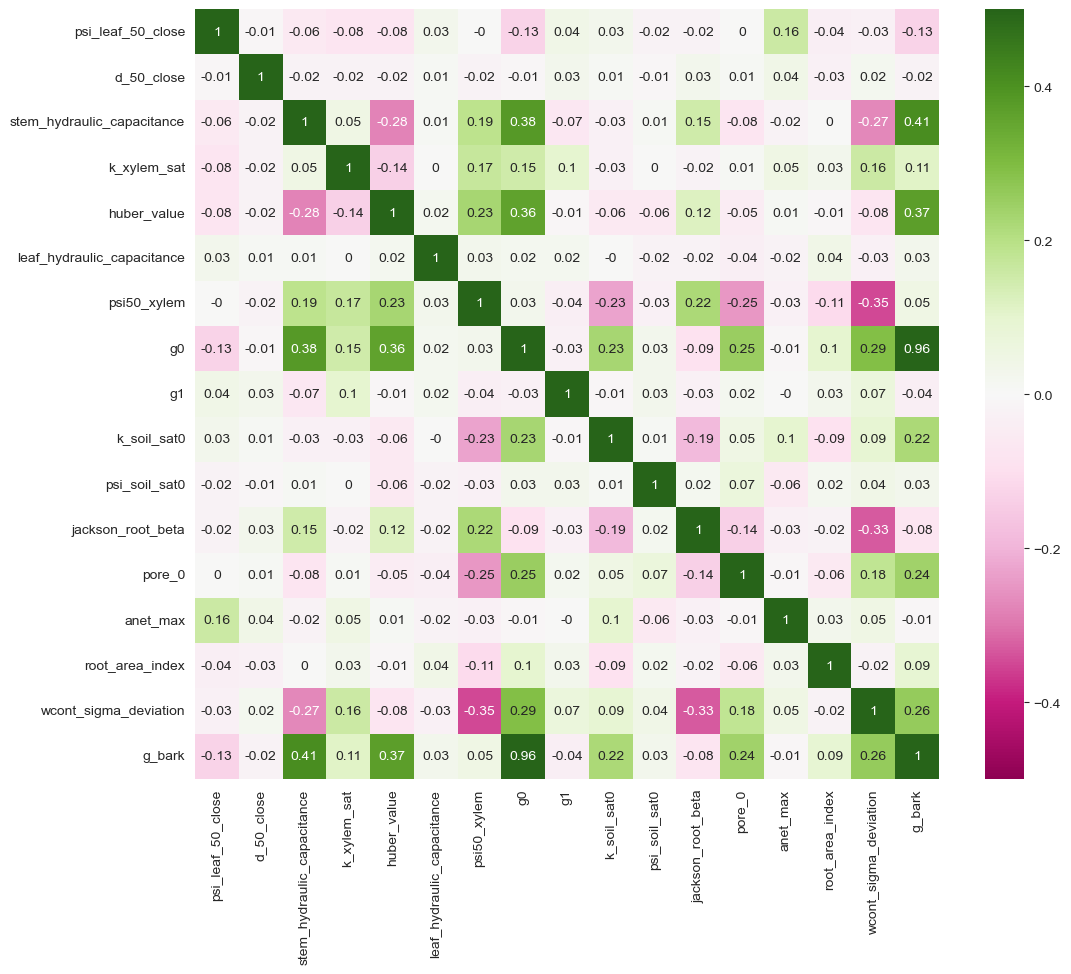

In [59]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")

<Axes: >

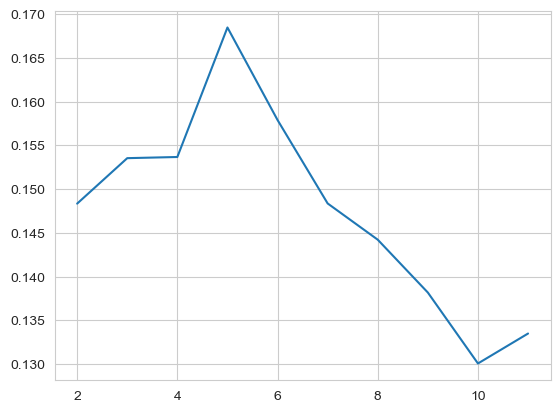

In [60]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state=2).fit(df_mean_norm[vars_plant])
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(df_mean_norm[vars_plant], model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

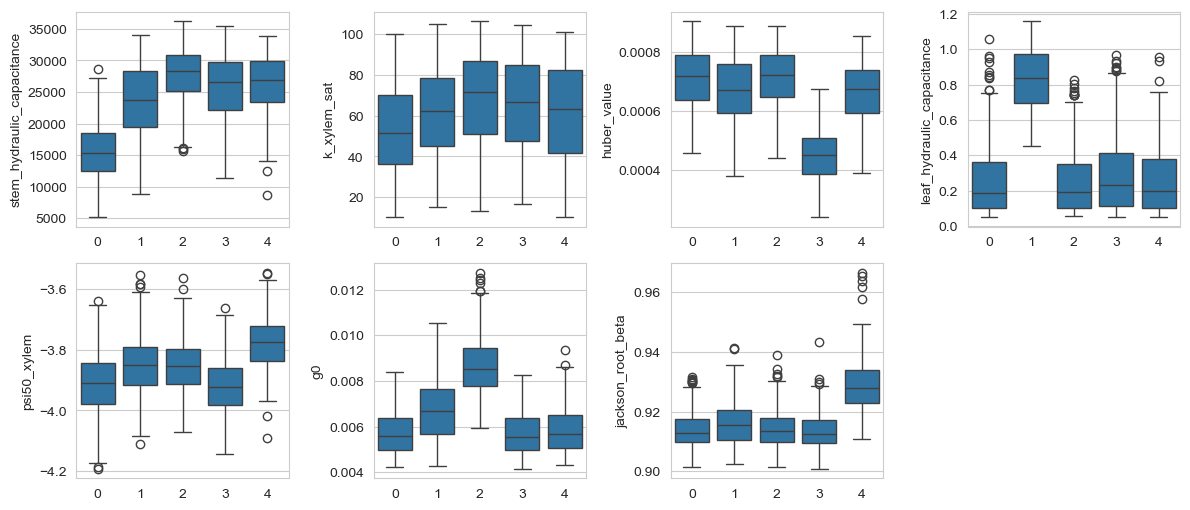

In [61]:
nclusters = 5
db = KMeans(n_clusters=nclusters, random_state=2)
db.fit(df_mean_norm[vars_plant])
cvals = [0.0, 1]
colors = ["red", "tab:blue"]

norm = plt.Normalize(min(cvals), max(cvals))
tuples = list(zip(map(norm, cvals), colors))
import matplotlib.colors

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)
fig = plt.figure(figsize=(12, 10))
for index, var in zip(np.arange(1, len(vars_plant) + 1), vars_plant):
    ax = fig.add_subplot(4, 4, index)
    sns.boxplot(x=db.labels_, y=df_mean[var], ax=ax)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()